In [ ]:
## visualization and data manipulation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

#models
from xgboost import XGBClassifier

## metrics
from sklearn.metrics import precision_score, recall_score, f1_score , make_scorer , mutual_info_score , ConfusionMatrixDisplay

## pipelines
from sklearn.pipeline import Pipeline , make_pipeline

## preprocessing
from sklearn.model_selection import train_test_split , learning_curve
from sklearn.model_selection import StratifiedKFold , cross_validate , RandomizedSearchCV , cross_val_predict
from sklearn.preprocessing import  StandardScaler , OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from pandas.plotting import scatter_matrix
import random

In [52]:
train0 = pd.read_csv("C:\\Users\\Simon\\OneDrive\\Desktop\\Decision trees 2.0\\train_churn.csv")
data = pd.read_csv('C:\\Users\\Simon\\OneDrive\\Desktop\\Decision trees 2.0\\test_churn.csv')
data_  , train_ = data.iloc[:501] , data.iloc[501:]
## set security as index
data_ = data_.set_index('security_no')
data_

,age,gender,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
security_no,,,,,,,,,,,,,,,,,,,,,
XT1XSHF,11,M,City,Silver Membership,02-06-2015,No,xxxxxxxx,Gift Vouchers/Coupons,?,Fiber_Optic,...,324.240000,26811.31,10,731.270000,No,Yes,No,Not Applicable,No reason specified,0
8M6FL97,55,F,City,Premium Membership,25-12-2015,Yes,CID34487,Without Offers,Desktop,Mobile_Data,...,159.570000,57136.11,17,791.170000,No,Yes,No,Not Applicable,Products always in Stock,0
5CR7U5V,10,M,NaN,Gold Membership,08-05-2016,Yes,CID41608,Gift Vouchers/Coupons,Smartphone,Wi-Fi,...,66.160000,35452.05,17,760.310000,Yes,No,Yes,Solved,Poor Product Quality,0
SAGM5C0,57,M,Village,Gold Membership,03-10-2016,?,CID5593,Gift Vouchers/Coupons,Smartphone,Wi-Fi,...,289.590000,11458.45,7,754.410000,Yes,No,Yes,Unsolved,No reason specified,0
5L27Y2R,23,F,City,Premium Membership,08-11-2016,Yes,CID4138,Gift Vouchers/Coupons,Smartphone,Mobile_Data,...,1247.161723,17844.36,5,1081.575461,No,Yes,Yes,Solved,Poor Website,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SBRCNKW,18,F,Town,Silver Membership,03-04-2017,?,CID16702,Credit/Debit Card Offers,Desktop,Fiber_Optic,...,117.890000,31104.70,5,680.760000,Yes,No,No,Not Applicable,Poor Customer Service,1
4NWFS7V,25,M,Town,Silver Membership,08-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,Smartphone,Wi-Fi,...,31.020000,17441.29,28,1281.093551,Yes,No,Yes,Solved,Poor Website,0
INYUVL4,49,F,Town,Gold Membership,09-12-2016,No,xxxxxxxx,Credit/Debit Card Offers,Desktop,Mobile_Data,...,52.610000,33445.41,16,434.020333,Yes,No,Yes,Solved,Quality Customer Care,0


In [53]:
## Make security_no the index of the dataframe
train1 = pd.concat([train0 , train_ ], axis = 0)
train = train1.set_index('security_no')
train.head()

,age,gender,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
security_no,,,,,,,,,,,,,,,,,,,,,
BYV5HD5,55,M,Town,Platinum Membership,08-06-2015,Yes,CID29201,Credit/Debit Card Offers,Smartphone,Wi-Fi,...,293.26,14829.26,23,764.43,Yes,Yes,Yes,Solved,Poor Website,0
5YJ4SCF,51,M,Town,Silver Membership,19-02-2017,?,CID518,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,34.00,10171.87,8,669.05,Yes,No,No,Not Applicable,Poor Customer Service,1
4R883CS,19,F,City,Gold Membership,04-08-2015,Yes,CID33644,Gift Vouchers/Coupons,?,Wi-Fi,...,567.56,24628.86,9,720.85,Yes,No,No,Not Applicable,Poor Customer Service,0
CQA8EUQ,64,M,Town,Gold Membership,25-12-2017,?,CID1451,Gift Vouchers/Coupons,?,Wi-Fi,...,461.58,25776.40,26,702.60,Yes,Yes,Yes,Solved,No reason specified,0
CK601TI,37,M,City,Silver Membership,05-12-2017,Yes,CID8971,Without Offers,Both,Mobile_Data,...,577.15,57996.82,11,772.52,Yes,Yes,Yes,Solved,Quality Customer Care,0


In [54]:
train.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36491.000000,36491.000000,36491.000000,36491.000000,33095.000000,36491.000000
mean,37.123702,-41.943411,243.624537,29277.383768,686.926242,0.541038
std,15.867789,228.879052,398.248312,19449.757329,193.924737,0.498320
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,0.000000
25%,23.000000,8.000000,60.175000,14190.445000,616.240000,0.000000
50%,37.000000,12.000000,161.950000,27543.120000,697.650000,1.000000
75%,51.000000,16.000000,356.285000,40853.420000,763.975000,1.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,1.000000


In [55]:
train_ = train.drop('churn_risk_score', axis = 1)
y = train[['churn_risk_score']]

In [56]:
train_df ,test_df, train_target , test_target = train_test_split( train_ , y, test_size = 0.20 , random_state = 42 , stratify = y)

In [57]:
eda_df = train_df.copy()

In [58]:
eda_df.info()


<class 'pandas.DataFrame'>
Index: 29192 entries, Y30FM4V to 2FBIOB2
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           29192 non-null  int64  
 1   gender                        29192 non-null  str    
 2   region_category               24891 non-null  str    
 3   membership_category           29192 non-null  str    
 4   joining_date                  29192 non-null  str    
 5   joined_through_referral       29192 non-null  str    
 6   referral_id                   29192 non-null  str    
 7   preferred_offer_types         28956 non-null  str    
 8   medium_of_operation           29192 non-null  str    
 9   internet_option               29192 non-null  str    
 10  last_visit_time               29192 non-null  str    
 11  days_since_last_login         29192 non-null  int64  
 12  avg_time_spent                29192 non-null  float64
 13  avg_trans

In [59]:
eda_df.isnull().sum()

age                                0
gender                             0
region_category                 4301
membership_category                0
joining_date                       0
joined_through_referral            0
referral_id                        0
preferred_offer_types            236
medium_of_operation                0
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                2731
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
dtype: int64

In [60]:
def check_val_counts(df, column):
    print(f"Value counts for {column}:")
    print(df[column].value_counts())

def check_unique(df, column):
    #print(f"Value counts for {column}:")
    #print(df[column].value_counts())
    #print("\n")
    return df[column].nunique()

for col in train_df.columns:
    unique_values = check_unique(train_df, col)
    print(f"Unique values for {col}: {unique_values}")


Unique values for age: 55
Unique values for gender: 3
Unique values for region_category: 3
Unique values for membership_category: 6
Unique values for joining_date: 1096
Unique values for joined_through_referral: 3
Unique values for referral_id: 9775
Unique values for preferred_offer_types: 3
Unique values for medium_of_operation: 4
Unique values for internet_option: 3
Unique values for last_visit_time: 24853
Unique values for days_since_last_login: 27
Unique values for avg_time_spent: 21562
Unique values for avg_transaction_value: 29134
Unique values for avg_frequency_login_days: 1295
Unique values for points_in_wallet: 19929
Unique values for used_special_discount: 2
Unique values for offer_application_preference: 2
Unique values for past_complaint: 2
Unique values for complaint_status: 5
Unique values for feedback: 9


In [61]:
train.loc[train['joined_through_referral'] == 'Yes' ,['joined_through_referral', 'churn_risk_score']]

,joined_through_referral,churn_risk_score
security_no,,
BYV5HD5,Yes,0
4R883CS,Yes,0
CK601TI,Yes,0
R59B7Q5,Yes,0
FDE1T7J,Yes,1
...,...,...
VD7KKZS,Yes,1
9KMMPWL,Yes,0
2VJCHXQ,Yes,1


In [62]:
train.loc[train['joined_through_referral'] == 'No' ,['referral_id','churn_risk_score']]

,referral_id,churn_risk_score
security_no,,
KZBOOHZ,xxxxxxxx,0
0WYQD5W,xxxxxxxx,1
JN00ETO,xxxxxxxx,1
94NKHU1,xxxxxxxx,0
1IDT8N2,xxxxxxxx,0
...,...,...
RBZBW8Z,xxxxxxxx,0
01YDDXI,xxxxxxxx,1
VV1DKWI,xxxxxxxx,1


In [63]:
negative_points_in_wallet = train.loc[train.points_in_wallet < 0 , ['points_in_wallet']]
negative_points_in_wallet

,points_in_wallet
security_no,
KZ8NTDH,-228.414121
6M9GDVZ,-196.591998
8T7S440,-174.834106
9GBMURW,-49.846043
7K3ULW9,-33.263494
...,...
UZFC848,-298.736774
1MSIN6E,-224.935188
O0TZ44Q,-55.377765


In [64]:
check_unique(eda_df, 'referral_id')

9775

In [65]:
check_val_counts(eda_df , 'feedback')

Value counts for feedback:
feedback
Poor Product Quality        5042
Poor Website                4956
No reason specified         4944
Too many ads                4934
Poor Customer Service       4914
Reasonable Price            1124
Products always in Stock    1121
User Friendly Website       1101
Quality Customer Care       1056
Name: count, dtype: int64


In [66]:
def consolidate_categories(x):
    eda_df_ = x.copy()
    
    positive = ['Reasonable Price', 'Products always in Stock', 
                'User Friendly Website', 'Quality Customer Care']
    negative = ['Too many ads', 'No reason specified', 'Poor Product Quality',
                'Poor Customer Service', 'Poor Website']
    neutral = ['No reason specified']
    
    mapping = {cat: 'positive' for cat in positive}
    mapping.update({cat: 'negative' for cat in negative})
    mapping.update({cat: 'neutral' for cat in neutral})
    
    eda_df_.feedback = eda_df_.feedback.replace(mapping)

    eda_df_['has_referral'] = (
        eda_df_['referral_id']
        .str.startswith('CID', na = False)
        .astype(int))
    ## We explicitly pass Yes and No as explicit values for joined through referral 
    values = ['Yes' , 'No']
    eda_df_['joined_through_referral'] = eda_df_.joined_through_referral.where(eda_df_.joined_through_referral.isin(values) , other = np.nan)
    eda_df_.joined_through_referral = eda_df_.joined_through_referral.astype('category')
    # Convert to datetime — pandas infers HH:MM:SS automatically
    eda_df_['last_visit_time'] = pd.to_datetime(eda_df_['last_visit_time'], format='%H:%M:%S')
    # Extract just the time component as a clean display
    eda_df_['last_visit_time'] = eda_df_['last_visit_time'].dt.strftime('%H:%M:%S')
    ## Replace 'Unknown' with ' Male ' denoted as M in the dataset
    eda_df_['gender'] = eda_df_['gender'].str.strip().replace('Unknown', 'M')
    ## Remove negative values in the avg_time_spent column and replace them with NaN
    eda_df_['avg_time_spent'] = eda_df_['avg_time_spent'].where(eda_df_['avg_time_spent'] >= 0, other = np.nan)
    ## We can see that there are some negative values in the days_since_last_login column which is not possible and we can coerce those values to NaN and then replace them with the median of the column
    eda_df_['days_since_last_login'] = eda_df_['days_since_last_login'].where(eda_df_['days_since_last_login'] >= 0 , other = np.nan)
    ## We coerce the ? in medium of operation to NaN , then replace the NaN with the Smartphone
    eda_df_['medium_of_operation'] = eda_df_['medium_of_operation'].replace('?', np.nan)
    eda_df_['medium_of_operation'] = eda_df_['medium_of_operation'].fillna('Smartphone')
    ## Let's coerce the error value in the average frequency login days column to numeric and replace it with NaN and then compute median on the now-clean numeric column
    eda_df_['avg_frequency_login_days'] = pd.to_numeric(
        eda_df_['avg_frequency_login_days'], errors='coerce')
    eda_df_['avg_frequency_login_days'] = eda_df_['avg_frequency_login_days'].where(eda_df_.avg_frequency_login_days >= 0 , other = np.nan)
    ### Let's Generate a code that will replace the joining_dates with joining_year and joining_month
    ## Joining date is a string and we can use pandas to_datetime function to convert it to datetime and then extract the year and month from it.
    eda_df_['joining_date'] = pd.to_datetime(eda_df_['joining_date'] , dayfirst = True)
    eda_df_['joining_month'] = eda_df_['joining_date'].dt.strftime('%m')
    eda_df_['joining_year'] = eda_df_['joining_date'].dt.strftime('%Y')
    eda_df_['joining_month'] = eda_df_['joining_month'].astype(int)
    eda_df_['joining_year'] = eda_df_['joining_year'].astype(int)
    ## We can drop the joining_date column now and apend joining_month and joining_year to the end of the dataframe
    eda_df_new = eda_df_.drop(['joining_date', 'referral_id'] , axis = 1 )
    ## Let us apply quantile based binning to the avg_frequency_login_days column and create a new column called avg_frequency_login_days_binned and also to the avg_time_spent_company column and create a new column called avg_time_spent_company_binned
    eda_df_new['avg_frequency_login_days_binned'] = pd.qcut(eda_df_new['avg_frequency_login_days'], q = 5, labels = False)
    eda_df_new['avg_time_spent_binned'] = pd.qcut( eda_df_new['avg_time_spent'] , q = 5, labels = False)
    ## Let's apply fixed width bining to the age column and create a new column called age_binned
    eda_df_new['age_binned'] = pd.cut(eda_df_new['age'], bins = 6 , labels = False)
    return eda_df_new
# Integrate into ML pipeline
encoder = FunctionTransformer(consolidate_categories)
eda_d = encoder.transform(eda_df)


In [67]:
output = eda_d.index.equals(train_target.index)
if output == False:
    train_target = train_target.loc[eda_d.index]
else:
    print(f'Feature dataframe and target are perfectly aligned')

Feature dataframe and target are perfectly aligned


In [68]:
print(type(train_target), train_target.shape)
train_target

<class 'pandas.DataFrame'> (29192, 1)


,churn_risk_score
security_no,
Y30FM4V,1
Q8C8ZCA,1
IA66T8S,1
F99RTQF,0
1XBU8VN,1
...,...
1525QFI,0
1PIADSA,0
GK9686P,0


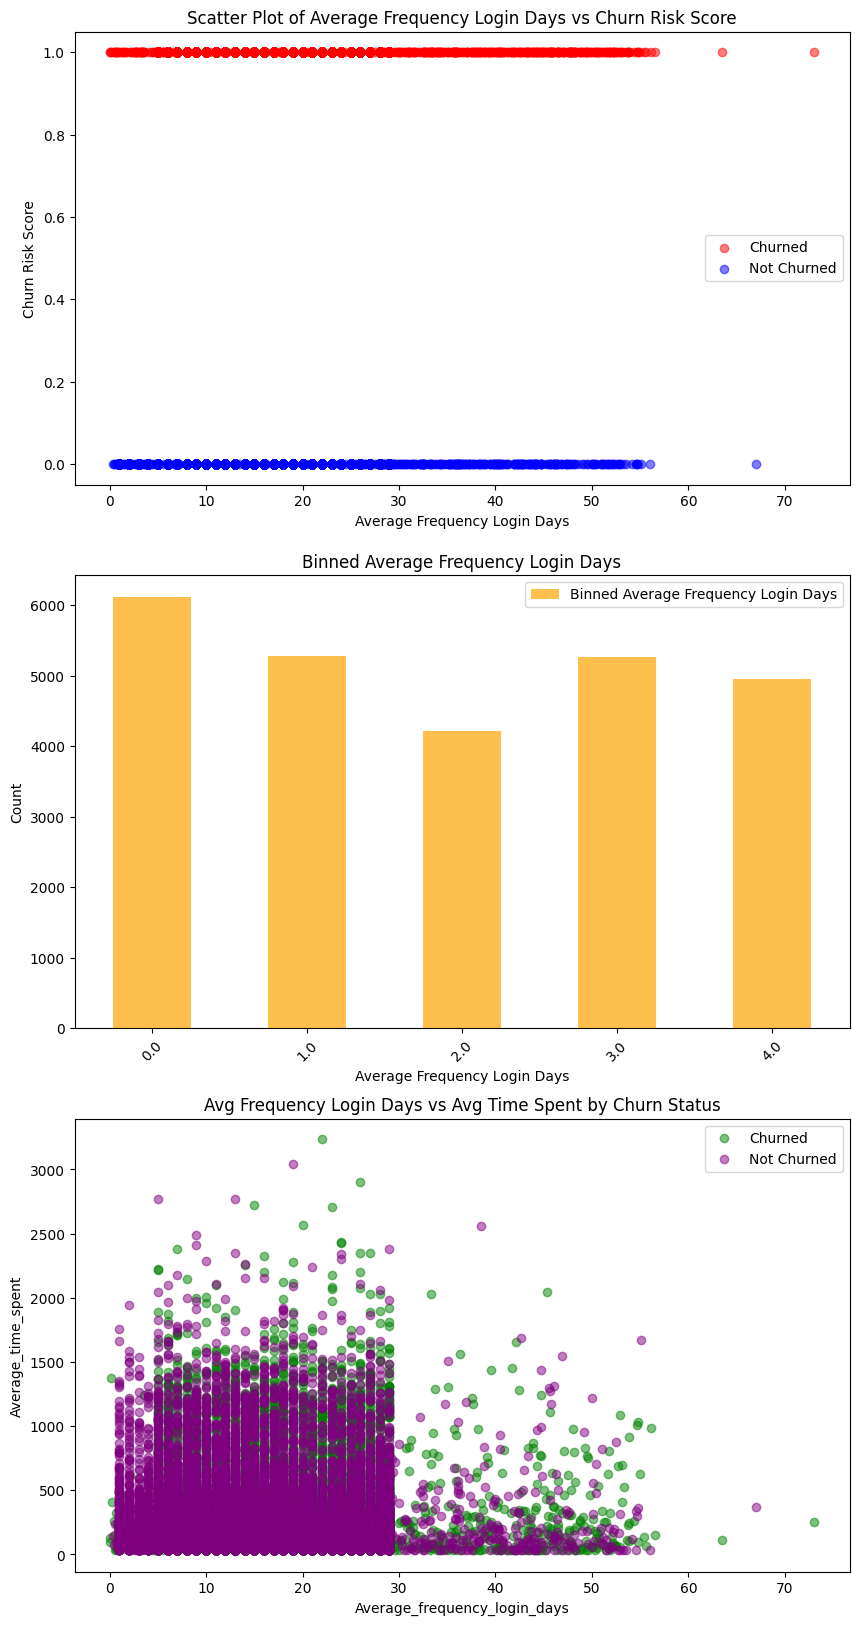

In [69]:
## Let's visualize the relationship between the average frequency login days and the churn risk score using a scatter plot
fig, ax = plt.subplots(3 , 1 , figsize=(10, 20))
pos = train_target.iloc[:,0] == 1  # now a clean 1D Series everywhere downstream
neg = train_target.iloc[:,0] == 0
ax[0].scatter( eda_d.loc[pos, 'avg_frequency_login_days'] , train_target[pos], color = 'red' , alpha = 0.5 , label = 'Churned')
ax[0].scatter( eda_d.loc[neg, 'avg_frequency_login_days'] , train_target[neg], color ='blue', alpha = 0.5, label = 'Not Churned')
ax[0].set_xlabel('Average Frequency Login Days')
ax[0].set_ylabel('Churn Risk Score')
ax[0].set_title('Scatter Plot of Average Frequency Login Days vs Churn Risk Score')
ax[0].legend()
# bar chart — correct way to visualise a binned categorical column
eda_d['avg_frequency_login_days_binned'].value_counts().sort_index().plot(kind = 'bar' , ax = ax[1] , color = 'orange' , alpha = 0.7 , label = 'Binned Average Frequency Login Days')
ax[1].set_title('Binned Average Frequency Login Days')
ax[1].set_xlabel('Average Frequency Login Days')
ax[1].set_ylabel('Count')
ax[1].legend()
ax[1].tick_params( axis = 'x', rotation = 45)
## Let's check the average frequency login days column and the avg_time_spent column and establish the re;ationship between them
ax[2].scatter(eda_d.loc[pos , 'avg_frequency_login_days'] , eda_d.loc[pos , 'avg_time_spent'] ,color='green',alpha=0.5,label='Churned')
ax[2].scatter(eda_d.loc[neg , 'avg_frequency_login_days'] , eda_d.loc[neg , 'avg_time_spent'] ,color='purple',alpha=0.5,label='Not Churned') 
ax[2].set_xlabel('Average_frequency_login_days')
ax[2].set_ylabel('Average_time_spent')
ax[2].set_title('Avg Frequency Login Days vs Avg Time Spent by Churn Status')
ax[2].legend()
plt.show()

In [70]:
eda_d.columns

Index(['age', 'gender', 'region_category', 'membership_category',
       'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'last_visit_time',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'has_referral', 'joining_month', 'joining_year',
       'avg_frequency_login_days_binned', 'avg_time_spent_binned',
       'age_binned'],
      dtype='str')

In [71]:
eda_d.info()

<class 'pandas.DataFrame'>
Index: 29192 entries, Y30FM4V to 2FBIOB2
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              29192 non-null  int64   
 1   gender                           29192 non-null  str     
 2   region_category                  24891 non-null  str     
 3   membership_category              29192 non-null  str     
 4   joined_through_referral          24908 non-null  category
 5   preferred_offer_types            28956 non-null  str     
 6   medium_of_operation              29192 non-null  str     
 7   internet_option                  29192 non-null  str     
 8   last_visit_time                  29192 non-null  str     
 9   days_since_last_login            27644 non-null  float64 
 10  avg_time_spent                   27836 non-null  float64 
 11  avg_transaction_value            29192 non-null  float64 
 12  avg_frequenc

In [72]:
check_val_counts( eda_d , 'feedback')

Value counts for feedback:
feedback
negative    19846
neutral      4944
positive     4402
Name: count, dtype: int64


In [73]:
check_val_counts(eda_d, 'gender')

Value counts for gender:
gender
M    14631
F    14561
Name: count, dtype: int64


In [74]:
## Write functions to fill in missing values for numerical and categorical features
def fill_missing_values_pandas(df):
    for column in df.select_dtypes(include='str').columns:
        df[column] = df[column].astype('category')
    for column in df.columns:
        if isinstance(df[column].dtype, pd.CategoricalDtype)   :  # Categorical feature
            df[column] = df[column].fillna(df[column].mode()[0], inplace=True)
        else:  # Numerical feature
            df[column] = df[column].fillna(df[column].median(), inplace=True)
    return df
## Write another function using scikit-learn's SimpleImputer to fill in missing values for numerical and categorical features
def fill_missing_values_sklearn(df):
    for column in df.select_dtypes(include='str').columns:
        df[column] = df[column].astype('category')
    for column in df.columns:
        if isinstance(df[column].dtype, pd.CategoricalDtype):  # Categorical feature
            imputer = SimpleImputer(strategy='most_frequent')
            x = imputer.fit_transform(df[[column]])
            ## Since the output of fit_transform is a 2D array/Sparse matrix, we need to recover the original shape ,index and name of the column
            df[column] = x.flatten()  # Flatten the 2D array to 1D
        else:  # Numerical feature
            imputer = SimpleImputer(strategy='median')
            x = imputer.fit_transform(df[[column]])
            ## Since the output of fit_transform is a 2D array/Sparse matrix, we need to recover the original shape ,index and name of the column
            flattened = x.flatten()  # Flatten the 2D array to 1D
            df[column] = pd.Series(flattened, index = df.index, name = column)
            # The output above 
            # "Converts this transformed sklearn output back into a proper pandas column while keeping the correct rows and column name
    return df
## Fill in missing values using the sklearn function
x_filled = fill_missing_values_sklearn(eda_d)
x_filled.head()

,age,gender,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,...,offer_application_preference,past_complaint,complaint_status,feedback,has_referral,joining_month,joining_year,avg_frequency_login_days_binned,avg_time_spent_binned,age_binned
security_no,,,,,,,,,,,,,,,,,,,,,
Y30FM4V,57.0,M,Village,Gold Membership,No,Gift Vouchers/Coupons,Smartphone,Fiber_Optic,06:21:04,6.0,...,Yes,Yes,Unsolved,neutral,0.0,5.0,2015.0,1.0,3.0,5.0
Q8C8ZCA,14.0,M,City,No Membership,Yes,Credit/Debit Card Offers,Smartphone,Mobile_Data,17:02:33,10.0,...,Yes,No,Not Applicable,negative,1.0,11.0,2017.0,4.0,2.0,0.0
IA66T8S,45.0,F,Village,Silver Membership,No,Gift Vouchers/Coupons,Desktop,Fiber_Optic,12:22:14,15.0,...,Yes,No,Not Applicable,negative,0.0,1.0,2015.0,0.0,1.0,3.0
F99RTQF,16.0,M,City,Platinum Membership,No,Gift Vouchers/Coupons,Smartphone,Wi-Fi,23:01:27,14.0,...,Yes,No,Not Applicable,neutral,0.0,8.0,2015.0,0.0,2.0,0.0
1XBU8VN,29.0,M,Town,No Membership,Yes,Without Offers,Smartphone,Mobile_Data,20:50:03,20.0,...,Yes,Yes,No Information Available,negative,1.0,6.0,2017.0,1.0,0.0,2.0


In [ ]:
# Variables gen below will be for

def plot_cross_validation(cv, # --> This ism not plain cross_val numbers but the method of cross validation used
                          train = x_filled, # data for training
                          target = train_target, # Testing
                          groups = x_filled['medium_of_operation'], 
                          n_splits = 4, # Number of splits 2, 3 and so on
                          lw=4
                          ):
    """Create a sample plot for indices of a cross-validation object."""
    Tgroup = "Group" in type(cv).__name__ # Extract type of cross validation method
    c_group = groups if Tgroup else None 
    # Generate the training/testing visualizations for each CV split
    for i, (r, t) in enumerate(cv.split(X=train, y=target, groups=c_group)):
        # i is the spit index i.e fold 0 and so on 
        # r is the array of indices chosen for Training in this split.
        # t is the array of indices chosen for Testing (Validation) in this split.
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(train))  # Creates an array equivalent to length of dataset
        indices[t] = 1 # Assigns 1 to those of validation 
        indices[r] = 0 # Assigns 0 to those of training

        # Visualize the results / Drawing the split folds
        ax.scatter(
            range(len(indices)),
            [i + 0.5] * len(indices), # Without this the folds will be like stacked blocks so for efficiency we spread out by .5 
            c=indices, # Assigns color depending on the indices assigned
            marker="_",
            lw=lw,
            cmap= plt.cm.coolwarm, # This refes to matplotlib's color diverinhg map, from deep blue to bright red
            # Maps the 0s (Training indices) to blue and the 1s (Test indices) to red
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot the data class Row and groups at the end
    ax.scatter(
        range(len(train)), [i + 1.5] * len(train), c=target, marker="_", lw=lw, cmap = plt.cm.Paired
    )

    ax.scatter(
        range(len(train)), [i + 2.5] * len(train), c=c_group, marker="_", lw=lw, cmap = plt.cm.Paired
    )

    # Formatting
    yticklabels = list(range(n_splits)) + ["class", "group"] # List labkes ofr the y axis
    ax.set(
        yticks=np.arange(n_splits + 2) + 0.5, 
        yticklabels=yticklabels,
        xlabel="Sample index", # Title for x axis
        ylabel="CV iteration", # Title for y axis
        ylim=[n_splits + 2.2, -0.2],
        xlim=[0, 100], # Sets boundaries for the x axis
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax
plot_cross_validation(StratifiedKFold(4))

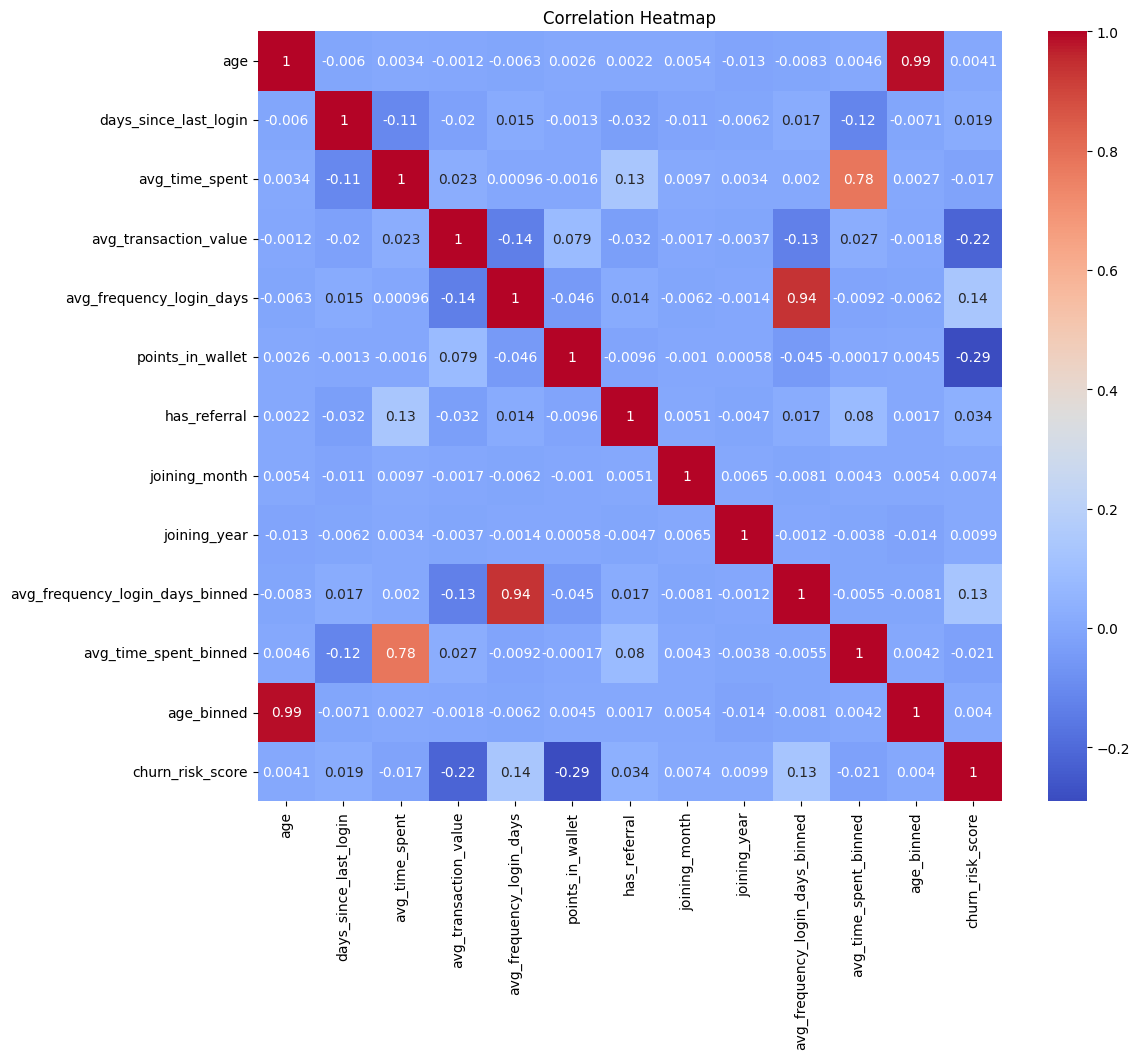

In [75]:
def corr_matrix_function(dataset , y):
    # Combine X and y temporarily
    df = pd.concat([dataset, y], axis=1)
    correlation = df.corr(numeric_only = True)
    plt.figure(figsize = (12, 10))
    sns.heatmap(correlation , annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap")
    plt.show()
corr_matrix_function(x_filled , train_target)

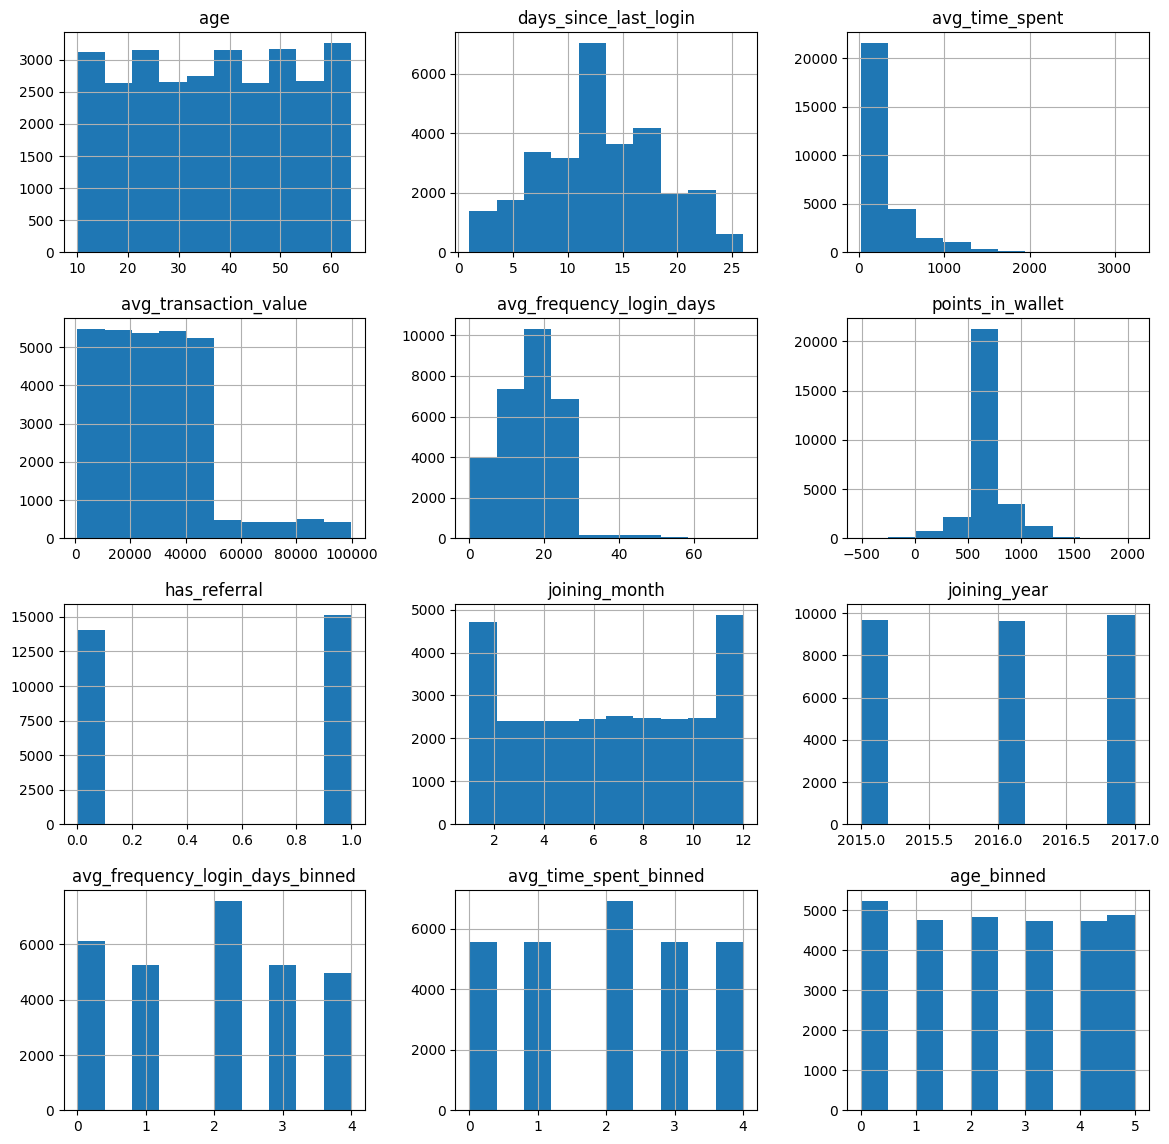

In [76]:
x_filled.hist(figsize=(14, 14))
plt.show()

In [77]:
def most_correlated_features(dataset,y ,threshold=0.2):
        # Combine X and y temporarily
    df = pd.concat([dataset, y], axis=1)

    # Correlation matrix
    corr = df.corr(numeric_only=True)

    # Target column name
    target_col = y.columns[0]

    # Features correlated with target above threshold
    most_correlated = [
        col for col in corr.columns
        if abs(corr.loc[col, target_col]) > threshold
        and col != target_col
    ]

    return most_correlated

In [78]:
most_correlated = most_correlated_features(x_filled , train_target)
most_correlated

['avg_transaction_value', 'points_in_wallet']

churn_risk_score
1                   0.541039
0                   0.458961
Name: proportion, dtype: float64


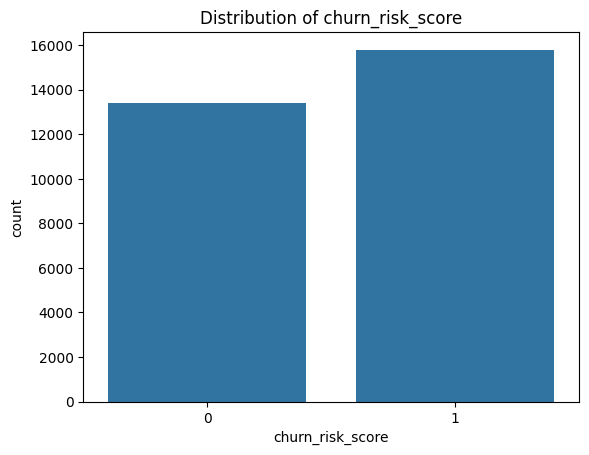

In [79]:
## Let's ensure we have a balanced dataset by checking the distribution of the target variable
distribution = train_target.value_counts(normalize = True)
print(distribution)
sns.countplot( x = train_target.columns[-1] , data = train_target)
plt.title(f'Distribution of {train_target.columns[0]}')
plt.show()

In [92]:
## Implementation of mutual information for feature selection
## Calculate mutual information scores for all features with respect to the target variable
## We write a function based to select the top features  if mutual information scores above a certain threshold of >= 0.5
def load_top_features_by_mi(df , y , threshold = 0.3):
    y1 = y.copy().squeeze()
    features_categorical = df.select_dtypes(include = ['str','object','category'])
    most_correlated = most_correlated_features(df ,y )
    features_numerical = df.select_dtypes(include = [np.number] )[most_correlated]
    mi_scores = {feature: mutual_info_score(df[feature], y1) for feature in features_categorical.columns}
    mi_scores = {feature: score for feature, score in mi_scores.items() if score >= threshold}
    selected_features  = pd.Series(mi_scores).sort_values(ascending = False)
    ## a dataframe containing numerical and most important categorical features
    selected_df = pd.concat([features_numerical, df[selected_features.index]], axis=1)
    return selected_df
top_df  = load_top_features_by_mi( x_filled , train_target)
top_df.head()

,avg_transaction_value,points_in_wallet,last_visit_time,membership_category
security_no,,,,
Y30FM4V,19591.76,625.570000,06:21:04,Gold Membership
Q8C8ZCA,30862.13,697.540000,17:02:33,No Membership
IA66T8S,19808.80,383.949075,12:22:14,Silver Membership
F99RTQF,8389.62,712.780000,23:01:27,Platinum Membership
1XBU8VN,42445.96,616.600000,20:50:03,No Membership


In [81]:
def log_transform(df):
        list_of_columns = ['avg_transaction_value' , 'points_in_wallet']
        for column in list_of_columns:
            # handles both negative and positive values safely
            df[column] = np.sign(df[column]) * np.log1p(np.abs(df[column])) # log1p is used to handle zero values
        df = df.drop(['last_visit_time'] , axis = 1)
        return df
top_df_transformed = log_transform(top_df)
## We write a function for one hot encoding the categorical features in the top_df
def one_hot_encode(df):
    categorical_cols = df.select_dtypes(include=['str' , 'object', 'category']).columns
    encoder = OneHotEncoder(drop='first' , sparse_output=False)  # drop='first' to avoid dummy variable trap
    encoded_data = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols) , index=df.index)
    df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1 , ignore_index=False)
    return df
top_df_encoded = one_hot_encode(top_df_transformed)
top_df_encoded.head()

,avg_transaction_value,points_in_wallet,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership
security_no,,,,,,,
Y30FM4V,9.882915,6.440260,1.0,0.0,0.0,0.0,0.0
Q8C8ZCA,10.337318,6.548992,0.0,1.0,0.0,0.0,0.0
IA66T8S,9.893932,5.953111,0.0,0.0,0.0,0.0,1.0
F99RTQF,9.034870,6.570575,0.0,0.0,1.0,0.0,0.0
1XBU8VN,10.656011,6.425841,0.0,1.0,0.0,0.0,0.0


In [82]:
def remove_index(df, y ):
    df = df.reset_index(drop = True)
    target = y.iloc[:,0]
    target1 =  target.reset_index(drop = True)
    return df , target1

In [83]:
train_df_ , train_target_ = remove_index(top_df_encoded , train_target )
train_df_.head()

,avg_transaction_value,points_in_wallet,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership
0,9.882915,6.440260,1.0,0.0,0.0,0.0,0.0
1,10.337318,6.548992,0.0,1.0,0.0,0.0,0.0
2,9.893932,5.953111,0.0,0.0,0.0,0.0,1.0
3,9.034870,6.570575,0.0,0.0,1.0,0.0,0.0
4,10.656011,6.425841,0.0,1.0,0.0,0.0,0.0


Model Training

In [ ]:
## Initially I combined all the hyperparameteres for all the models in a single dictionary to perform a randomized search across all the models at once
# and then I received a 'RandomizedSearchCV' object is not iterable, I realized that it is not possible to do that because the parameters for each model are different and we need to specify the parameters
# for each model separately in the RandomizedSearchCV function. So I will write a separate dictionary for each model and then perform a randomized search for each model separately.
# Utility function to report best scores
def report_best_scores(results, rank_metric , n_top = 1):
    """
    Print top-n parameter configs from RandomizedSearchCV cv_results_.

    Parameters
    ----------
    results      : clf.cv_results_  (after fitting RandomizedSearchCV)
    n_top        : Top rank to display
    rank_metric  : which scorer to rank by — must match a key in your scoring dict
    """
    rank_key = f'rank_test_{rank_metric}'
    mean_key = f'mean_test_{rank_metric}'
    std_key  = f'std_test_{rank_metric}'
    
    print(f"\n{'='*60}")
    print(f"  Top Configurations  (ranked by {rank_metric})")
    print(f"{'='*60}")

    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results[rank_key] == i)
        if len(candidates) > 1:
            candidate = candidates[0]  # In case of ties, just take the first one
            print("Model with rank: {0}".format(i))
            print(
                    "Mean validation score: {0:.3f} (std: {1:.3f})".format(
                        results[mean_key][candidate],
                        results[std_key][candidate],
                    )
                )
            print("Parameters: {0}".format(results["params"][candidate]))
            print("")
        else:
            candidate = candidates[0]
            print("Model with rank: {0}".format(i))
            print(f"Mean {rank_metric.title()}: {results[mean_key][candidate]:.4f}")
            print(f"Std  {rank_metric.title()}: {results[std_key][candidate]:.4f}")
            print(f"Parameters: {results['params'][candidate]}\n")

def model_train(df , y , model , f , cross_val = cross_validate , fold = StratifiedKFold):
    """
    Train a model (or RandomizedSearchCV wrapper) and print per-metric scores.
    Returns cv_score dict so rank_models_by_f1() can consume it.
    """
    strat_ = fold(n_splits = 4 , shuffle = True , random_state = 1)
    print(f"Training using {model.__class__.__name__}")
    cv_score = cross_val(model , df , y , cv = strat_ , scoring = f)
    for metric in ['test_precision_score', 'test_recall_score', 'test_f1_score']:
        scores   = cv_score[metric]
        fold_str = '  '.join(f'{s:.3f}' for s in scores)       # fix: format each fold
        print(f"\n  {metric.removeprefix('test_')}:")
        print(f"    Folds  : [ {fold_str} ]")
        ## Add a new line to separate the metrics for better readability         # [0.83, 0.81, 0.85, 0.82, 0.84] # 0.83
        print('mean score:{0:.2f} (std: {1:.2f})\n'.format(scores.mean(), scores.std()))# tells you how stable the model is across folds

    return cv_score['test_f1_score'].mean()  # Return mean F1 score for ranking

## A fuction to rank the models based on their f1 score
def rank_models_by_f1(scores_dict):
    """
    Rank models based on their mean F1 scores from cross-validation.

    Parameters
    ----------
    scores_dict : dict
        Dictionary where keys are model names and values are mean F1 scores.

    Returns
    -------
    ranked_models : list of tuples
        List of (model_name, f1_score) tuples sorted by F1 score in descending order.
        
    """
    ranked_models = sorted(scores_dict.items(), key = lambda item: item[1], reverse = True)
    
    print(f"\n{'='*60}")
    print("  Model Rankings Based on Mean F1 Score")
    print(f"{'='*60}")
    
    for rank, (model_name, f1_score) in enumerate(ranked_models, start=1):
        print(f"Rank {rank}: {model_name} with Mean F1 Score = {f1_score:.4f}")


scoring = {'precision_score' : make_scorer(precision_score) ,'recall_score' : make_scorer(recall_score) ,'f1_score' : make_scorer(f1_score)}



#scores = {}    # collects cv results per model for ranking

#for model, param_distributions in model_param_pairs:
    #clf = RandomizedSearchCV(estimator = model, param_distributions = param_distributions, 
                             #n_iter = 7, cv = 4, refit = 'f1_score', random_state = 1 , n_jobs = -1
                             #,scoring = scoring)
    #model_name = type(model).__name__
    #clf.fit(train_df_ , train_target_)
    #best_model = clf.best_estimator_
    #report_best_scores(clf.cv_results_ , rank_metric = 'f1_score')
    #scores[model_name] = model_train(train_df_ , train_target_ ,best_model, scoring, cross_validate)
#rank_models_by_f1(scores)

It's obvious The RandomForest with parameters
'max_depth': 14, 'max_features': 'log2', 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': np.int64(279)
 offers better trade off for both precision and recall


Model training with XGBoosting

In [ ]:
#clf = RandomizedSearchCV(estimator = model, param_distributions = XGB_param,
                         #n_iter = 20, cv = 4, random_state = 1 , n_jobs = -1,
                         #scoring = scoring , refit = 'f1_score')
#clf.fit(train_df_ , train_target_)
#m_name = clf.best_estimator_
#report_best_scores(clf.cv_results_, rank_metric = 'f1_score')
#model_train(train_df_ , train_target_ , m_name , scoring)

we continue with XGBOOSTING , it outperforms the previous classfiers


In [ ]:
## Implement gradient boosting classifier with the best hyperparameters obtained from the randomized search
GB_clf = make_pipeline( StandardScaler() , XGBClassifier(learning_rate = np.float64(0.0115388019461499), max_depth = 7, n_estimators = 505, random_state = 1, verbosity = 0))
## Let's plot Precision-Recall curve and ROC curve for the model
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
##  class probabilities for every instance in the training set
y_scores = cross_val_predict(GB_clf, train_df_, train_target_, cv = 4, method='predict_proba')[:, 1]  # Get probabilities for the positive class
# Get probabilities for the positive class
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(train_target_, y_scores)
fpr_forest, tpr_forest, thresholds_roc_forest = roc_curve(train_target_ , y_scores)
## The default threshold is 0.5, so let's find the threshold for 99% recall , 95% precision, 90% precision and 92% precision
Idx_99_recall , idx_95_precision , idx_for_92_precision , idx_for_90_precision = np.argmax(recalls_forest >= 0.99), np.argmax(precisions_forest >= 0.95) , np.argmax(precisions_forest >= 0.92) , np.argmax(precisions_forest >= 0.90)
threshold_99_recall , threshold_95_precision , threshold_92_precision , threshold_90_precision = thresholds_forest[Idx_99_recall] , thresholds_forest[idx_95_precision] ,thresholds_forest[idx_for_92_precision] , thresholds_forest[idx_for_90_precision]
## To make predictions based on the custom thresholds, we can use the following code:
y_pred_99_recall = (y_scores >= threshold_99_recall).astype(int)
y_pred_95_precision = (y_scores >= threshold_95_precision).astype(int)
y_pred_92_precision = (y_scores >= threshold_92_precision).astype(int)
y_pred_90_precision = (y_scores >= threshold_90_precision).astype(int)
##Let's check precision and recall for these custom thresholds and print the results
precision_99_recall = precision_score(train_target_, y_pred_99_recall)
recall_99_recall = recall_score(train_target_, y_pred_99_recall)
precision_95_precision = precision_score(train_target_, y_pred_95_precision)
recall_95_precision = recall_score(train_target_, y_pred_95_precision)
precision_92_precision = precision_score(train_target_, y_pred_92_precision)
recall_92_precision = recall_score(train_target_, y_pred_92_precision)
precision_90_precision = precision_score(train_target_, y_pred_90_precision)
recall_90_precision = recall_score(train_target_, y_pred_90_precision)
print(f"Precision at 99% recall: {precision_99_recall:.4f}" ,f"Recall at 99% recall: {recall_99_recall:.4f}") 
print(f"Precision at 95% precision: {precision_95_precision:.4f}" ,f"Recall at 95% precision: {recall_95_precision:.4f}")
print(f"Precision at 92% precision: {precision_92_precision:.4f}" ,f"Recall at 92% precision: {recall_92_precision:.4f}")
print(f"Precision at 90% precision: {precision_90_precision:.4f}" ,f"Recall at 90% precision: {recall_90_precision:.4f}")
print(f"Threshold for 99% recall: {threshold_99_recall:.4f}")
print(f"Threshold for 95% precision: {threshold_95_precision:.4f}")
print(f"Threshold for 92% precision: {threshold_92_precision:.4f}")
print(f"Threshold for 90% precision: {threshold_90_precision:.4f}")
print(f"Index for 99% recall: {Idx_99_recall}" , f"Index for 95% precision: {idx_95_precision}" , f"Index for 92% precision: {idx_for_92_precision}" , f"Index for 90% precision: {idx_for_90_precision}")

Precision at 99% recall: 0.5410 Recall at 99% recall: 1.0000
Precision at 95% precision: 0.9500 Recall at 95% precision: 0.9257
Precision at 92% precision: 0.9200 Recall at 92% precision: 0.9521
Precision at 90% precision: 0.9001 Recall at 90% precision: 0.9706
Threshold for 99% recall: 0.0019
Threshold for 95% precision: 0.5022
Threshold for 92% precision: 0.4528
Threshold for 90% precision: 0.4169
Index for 99% recall: 0 Index for 95% precision: 2191 Index for 92% precision: 1836 Index for 90% precision: 1600


AUC score for the ROC curve: 0.9741


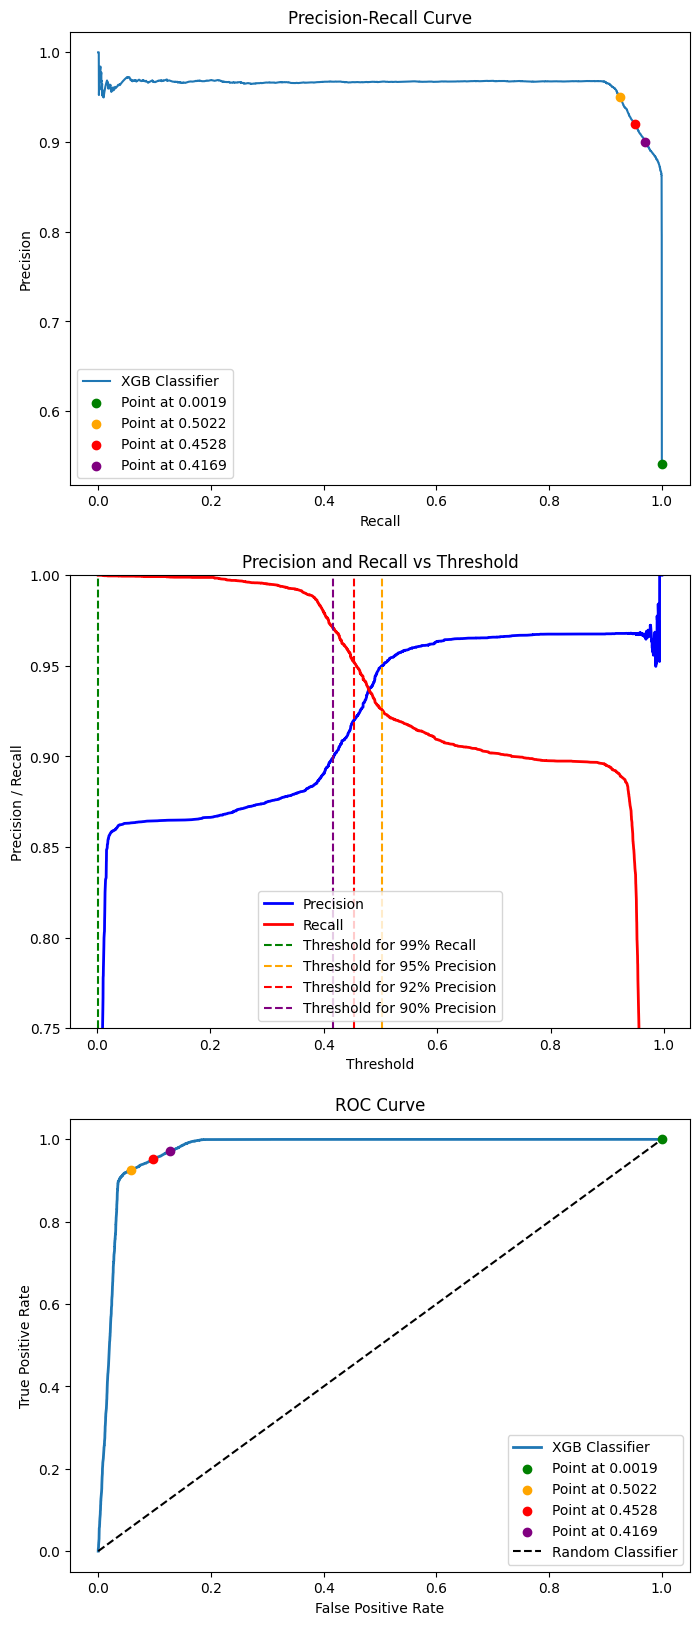

In [87]:
idx_threshold_roc_99_recall = (thresholds_roc_forest <= threshold_99_recall).argmax()
fpr_99_recall , tpr_99_recall = fpr_forest[idx_threshold_roc_99_recall] , tpr_forest[idx_threshold_roc_99_recall]
idx_threshold_roc_95_precision = (thresholds_roc_forest <= threshold_95_precision).argmax()
fpr_95_precision , tpr_95_precision = fpr_forest[idx_threshold_roc_95_precision] , tpr_forest[idx_threshold_roc_95_precision]
idx_threshold_roc_92_precision = (thresholds_roc_forest <= threshold_92_precision).argmax()
fpr_92_precision , tpr_92_precision = fpr_forest[idx_threshold_roc_92_precision] , tpr_forest[idx_threshold_roc_92_precision]
idx_threshold_roc_90_precision = (thresholds_roc_forest <= threshold_90_precision).argmax()
fpr_90_precision , tpr_90_precision = fpr_forest[idx_threshold_roc_90_precision] , tpr_forest[idx_threshold_roc_90_precision]
## Obtain the AUC score for the ROC curve
roc_auc_forest = roc_auc_score(train_target_ , y_scores)
print(f"AUC score for the ROC curve: {roc_auc_forest:.4f}")
## Let's plot the Precision-Recall curve and ROC curve for the Random Forest model
fig, ax = plt.subplots(3 , 1 ,figsize = (8, 20))
## Precision-Recall curve
ax[0].plot(recalls_forest, precisions_forest, label='XGB Classifier')
## Plot the points corresponding to the custom thresholds on the Precision-Recall curve
ax[0].scatter(recalls_forest[Idx_99_recall], precisions_forest[Idx_99_recall], color='green', label=f'Point at {threshold_99_recall:.4f}', zorder=5)
ax[0].scatter(recalls_forest[idx_95_precision], precisions_forest[idx_95_precision], color='orange', label=f'Point at {threshold_95_precision:.4f}', zorder=5)
ax[0].scatter(recalls_forest[idx_for_92_precision], precisions_forest[idx_for_92_precision], color='red', label=f'Point at {threshold_92_precision:.4f}', zorder=5)
ax[0].scatter(recalls_forest[idx_for_90_precision], precisions_forest[idx_for_90_precision], color='purple', label=f'Point at {threshold_90_precision:.4f}', zorder=5)
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall Curve')
ax[0].legend()

## Plot precision and recall as functions of the threshold value
ax[1].plot(thresholds_forest, precisions_forest[:-1], label='Precision', c = 'blue', linewidth = 2)
ax[1].plot(thresholds_forest, recalls_forest[:-1], label='Recall', c = 'red', linewidth = 2)
ax[1].axvline(x = threshold_99_recall, c ='green', linestyle='--', label='Threshold for 99% Recall')
ax[1].axvline(x = threshold_95_precision, c = 'orange', linestyle='--', label='Threshold for 95% Precision')
ax[1].axvline(x = threshold_92_precision, c = 'red', linestyle='--', label='Threshold for 92% Precision')
ax[1].axvline(x = threshold_90_precision, c = 'purple', linestyle='--', label='Threshold for 90% Precision')
ax[1].set_xlabel('Threshold')
ax[1].set_ylabel('Precision / Recall')
ax[1].set_title('Precision and Recall vs Threshold')
ax[1].set_ylim(0.75, 1)
ax[1].legend()

## Plot ROC curve
ax[2].plot(fpr_forest, tpr_forest, linewidth = 2, label = 'XGB Classifier')
ax[2].scatter(fpr_99_recall, tpr_99_recall, color='green', label=f'Point at {threshold_99_recall:.4f}', zorder=5)
ax[2].scatter(fpr_95_precision, tpr_95_precision, color='orange', label=f'Point at {threshold_95_precision:.4f}', zorder=5)
ax[2].scatter(fpr_92_precision, tpr_92_precision, color='red', label=f'Point at {threshold_92_precision:.4f}', zorder=5)
ax[2].scatter(fpr_90_precision, tpr_90_precision, color='purple', label=f'Point at {threshold_90_precision:.4f}', zorder=5)
ax[2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # Diagonal line for random classifier
ax[2].set_xlabel('False Positive Rate')
ax[2].set_ylabel('True Positive Rate')
ax[2].set_title('ROC Curve')
ax[2].legend()
plt.show()

## Confusion Matrix


In [ ]:
from sklearn.metrics import confusion_matrix

disp =  ConfusionMatrixDisplay.from_estimator(
    GB_clf,
    train_df,
    train_target,
    display_labels = train_target.target_names,
    cmap = plt.cm.Blues,
    normalize =  True,
)

disp.ax_.set_title("Normalied Confusion Matrix")
print(disp.confusion_matrix)

plt.show()

Confusion matrix with maatplotlib for more of the heavy lifting

In [ ]:
# We first define our matrix
confmat = confusion_matrix(y_true =  train_target_ , y_pred  = y_scores)
# define plots 
fig , ax = plt.subplots(figsize = (6,6))
plt.matshow(confmat , alpha = 0.6 , cmap = plt.cm.Blues)
# Define how the matrix is built
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x = i , y = j , s = confmat[i,j],
                va = "center" , ha = "center")
ax.axis.set_ticks_bottom()
ax.title("Confusion Matrix")
ax.get_xlabel("True label")
ax.get_ylabel("Pred label")

In [88]:
## Apply this on train
y_pred = (y_scores >= threshold_90_precision)
print("=" * 50)
print(f"TRAIN SET (threshold = {threshold_90_precision:.4f})")
print("=" * 50)
print(f"Precision score : {precision_score(train_target_ , y_pred)}")
print(f"Recall score : {recall_score(train_target_ , y_pred)}")
print(f"AUC score for the ROC curve: {roc_auc_score(train_target_ , y_pred):.4f}\n")

TRAIN SET (threshold = 0.4169)
Precision score : 0.9000704556129638
Recall score : 0.9706217550968722
AUC score for the ROC curve: 0.9218



In [100]:
def full_transformation(data , target):
     full_pipeline = make_pipeline(
          FunctionTransformer(consolidate_categories,
                              validate=False),
     
          FunctionTransformer(fill_missing_values_sklearn,
                              validate=False)).transform(data)
     test_df_ = pd.DataFrame(full_pipeline)
     test_df_1 = load_top_features_by_mi(test_df_ , target )
     log_transformer = FunctionTransformer(log_transform)
     test_df_2 = log_transformer.transform(test_df_1)
     encoder = FunctionTransformer(one_hot_encode)
     test_df_3 = encoder.transform(test_df_2)
     test_df_4 , test_target_ = remove_index(test_df_3 , target )

     return test_df_4 , test_target_
test_df_ , test_target_ = full_transformation(test_df , test_target)


In [101]:
test_df_.head()

,avg_transaction_value,points_in_wallet,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership
0,11.281703,6.724325,0.0,0.0,1.0,0.0,0.0
1,10.333403,6.549794,0.0,0.0,1.0,0.0,0.0
2,10.414537,6.606123,0.0,0.0,0.0,1.0,0.0
3,11.204558,6.679335,1.0,0.0,0.0,0.0,0.0
4,10.655898,6.324144,0.0,1.0,0.0,0.0,0.0


In [102]:
##Apply on testset
y_val_scores = GB_clf.fit(train_df_ , train_target_).predict_proba(test_df_)[:,1]
y_val_pred =  (y_val_scores >= threshold_90_precision)
print("=" * 50)
print(f"VALIDTION SET (threshold = {threshold_90_precision :.4f})")
print("=" * 50)
print(f"Precision score : {precision_score(test_target_ , y_val_pred)}")
print(f"Recall score : {recall_score(test_target_ , y_val_pred)}")
print(f'AUC score for the ROC curve: {roc_auc_score(test_target_ , y_val_pred):.4f}')

VALIDTION SET (threshold = 0.4169)
Precision score : 0.896979630063217
Recall score : 0.970119017472778
AUC score for the ROC curve: 0.9194


The Model does well on the above validation data now on the test set

In [103]:
val_target = data_[['churn_risk_score']]
val_target

,churn_risk_score
security_no,
XT1XSHF,0
8M6FL97,0
5CR7U5V,0
SAGM5C0,0
5L27Y2R,0
...,...
SBRCNKW,1
4NWFS7V,0
INYUVL4,0


In [104]:
val_data = data_.drop(columns = 'churn_risk_score')
val_test , val_test_target = full_transformation(val_data , val_target)

In [105]:
val_test

,avg_transaction_value,points_in_wallet,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership
0,10.196616,6.596149,0.0,0.0,0.0,0.0,1.0
1,10.953209,6.674776,0.0,0.0,0.0,1.0,0.0
2,10.475965,6.635041,1.0,0.0,0.0,0.0,0.0
3,9.346570,6.627261,1.0,0.0,0.0,0.0,0.0
4,9.789499,6.987098,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
496,10.345146,6.524678,0.0,0.0,0.0,0.0,1.0
497,9.766653,7.156250,0.0,0.0,0.0,0.0,1.0
498,10.417700,6.075393,1.0,0.0,0.0,0.0,0.0
499,10.687107,6.545946,0.0,1.0,0.0,0.0,0.0


In [106]:
y_test_scores = GB_clf.predict_proba(val_test)[:,1]
y_test_pred =  ( y_test_scores >= threshold_90_precision ) 
print("=" * 50)
print(f"TEST SET (threshold = {threshold_90_precision :.4f})")
print("=" * 50)
print(f"Precision score : {precision_score(val_test_target  , y_test_pred)}")
print(f"Recall score : {recall_score(val_test_target , y_test_pred)}")
print(f'AUC score for the ROC curve: {roc_auc_score(val_test_target , y_test_pred):.4f}')

TEST SET (threshold = 0.4169)
Precision score : 0.8922558922558923
Recall score : 0.9851301115241635
AUC score for the ROC curve: 0.9236
